In [112]:
from openmm.app import *
from openmm import *
from openmm.unit import *
from sys import stdout
from openmmtools.integrators import LangevinIntegrator, LangevinSplittingGirsanov
import matplotlib

import torch
from torch import nn, optim, autograd
from torch.nn import functional as F
from torch.utils.data.dataset import random_split
from openmmtorch import TorchForce

import numpy as np
from matplotlib import pyplot as plt

import gc

from scipy.stats import gaussian_kde
from scipy.interpolate import CubicSpline
from scipy.spatial import cKDTree

from pymbar import MBAR

from potential import *
from fmrc import *

import warnings
warnings.filterwarnings('ignore')

In [113]:
##############################################################################
# Global parameters
##############################################################################
mass = 1.0 * dalton
temp = 298.15
temperature = temp * kelvin
collision_rate = 10 / picosecond
timestep = 5 * femtosecond
splitting = 'R V O V R'
nstxout = 20
kt = temp*8.314/1000
platform = Platform.getPlatformByName('CUDA')

#### 0. Unbiased Simulation as Reference

##### 0.1 Mueller Brown Potential

In [17]:
# Simulation setup
n_sim = 10
n_iters = 1000000

# Run 2D Muller Brown simulation
system = System()
systemforce = MullerForce()
starting_positions = np.concatenate(
    [np.tile([-0.57,1.43,0],(int(n_sim/2),1)),
     np.tile([0.6,0.05,0],(int(n_sim/2),1)),],axis=0
)

# For unbiased simulation, we can parallelize the independent runs.
for n in range(n_sim):
    system.addParticle(mass)
    systemforce.addParticle(n, [])
system.addForce(systemforce)

topology = app.Topology()

# Langevin integrator that allows girsanov reweighting factor output
integrator = LangevinSplittingGirsanov(
    nstxout = nstxout, temperature = temperature,collision_rate = collision_rate,
    timestep = timestep, splitting = splitting
)

# Create simulation
simulation = Simulation(topology,system,integrator,platform)
simulation.context.setPositions(starting_positions)
simulation.context.setVelocitiesToTemperature(temperature)

In [18]:
%%time
save_dir = 'traj_and_dat/2d_muller/unbiased_{n_sim}x{n_iters}.npy'.format(
    n_sim = n_sim, n_iters = n_iters
)

# Notice we are now running 2D simulations
data = np.zeros((n_sim,n_iters,2))
for j in range(n_iters):
    if j % 1000 == 0:
        print(str(j)+'/'+str(n_iters))
    data[:,j,:] = simulation.context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(nanometer)[:,:2]
    simulation.step(nstxout)

np.save(save_dir,data)

0/1000000
1000/1000000
2000/1000000
3000/1000000
4000/1000000
5000/1000000
6000/1000000
7000/1000000
8000/1000000
9000/1000000
10000/1000000
11000/1000000
12000/1000000
13000/1000000
14000/1000000
15000/1000000
16000/1000000
17000/1000000
18000/1000000
19000/1000000
20000/1000000
21000/1000000
22000/1000000
23000/1000000
24000/1000000
25000/1000000
26000/1000000
27000/1000000
28000/1000000
29000/1000000
30000/1000000
31000/1000000
32000/1000000
33000/1000000
34000/1000000
35000/1000000
36000/1000000
37000/1000000
38000/1000000
39000/1000000
40000/1000000
41000/1000000
42000/1000000
43000/1000000
44000/1000000
45000/1000000
46000/1000000
47000/1000000
48000/1000000
49000/1000000
50000/1000000
51000/1000000
52000/1000000
53000/1000000
54000/1000000
55000/1000000
56000/1000000
57000/1000000
58000/1000000
59000/1000000
60000/1000000
61000/1000000
62000/1000000
63000/1000000
64000/1000000
65000/1000000
66000/1000000
67000/1000000
68000/1000000
69000/1000000
70000/1000000
71000/1000000
72000

#### 1. FMRC Dimensionality Reduction
To make discretization and visualization easier, we reduce the dimension of the system from 2 to 1 using the FMRC algorithm with the unbiased simulation as training data. We also postulate that the deposition of bias on a 1D collective variable will have a milder effect on the path ensemble, so that Girsanov reweighting will perform better.

In [114]:
# Read unbiased simulation data
# Using only the first trajectory and stride the trajectory for faster training
data_ref = np.load('traj_and_dat/2d_muller/unbiased_10x1000000.npy')[0]
data_ref.shape

(1000000, 2)

In [115]:
# TICA pre-processing
dim = None
var_cutoff = None
koopman = False
tica_lagtime = 1    # This is 1ps

# TICA pre-processing
tica,tica_output,tica_output_concat = run_TICA(data_ref,tica_lagtime,dim,var_cutoff,koopman)
data_input = [tica_output]
input_size = tica_output.shape[1]

In [116]:
### FMRC parameters
# FMRC training
fmrc_lagtime = tica_lagtime
latent_size = 1
hidden_size = 16
hidden_depth = 3
activation = nn.ReLU()
sigma = 0.001
learning_rate = 0.001
lr_decay = 0.1
lr_decay_stepsize = 50
val_frac = 0.1
batch_size = 512
n_epochs = 100
device = 'cuda'

In [22]:
%%time
# FMRC
fmrc = FMRC(input_size,latent_size,hidden_size,hidden_depth,activation,sigma,learning_rate,lr_decay,
                lr_decay_stepsize,val_frac,batch_size,n_epochs,device)
print(fmrc)
fmrc.fit(data_input,fmrc_lagtime)
fmrc.save_model('models/muller_2d.pt')

FMRC(
  (activation): ReLU()
  (encoder): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
  (L_vector_field): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=2, bias=True)
  )
  (D_vector_field): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=2, bias=True)
  )
)
Epoch 1: T

In [117]:
fmrc = torch.load('models/muller_2d.pt')

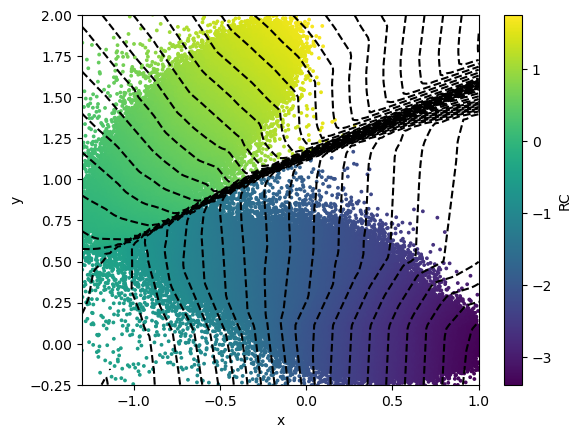

In [118]:
# Transform into FMRC space and normalize
r = fmrc.transform(tica_output)

# Visualize
markersize = 3
stride = 1

fig,ax = plt.subplots()


sc = ax.scatter(data_ref[:,0][::stride],data_ref[:,1][::stride],c=r[::stride],s=markersize)
plt.colorbar(sc,label='RC')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim([MullerForce().x_range[0],MullerForce().x_range[1]])
ax.set_ylim([MullerForce().y_range[0],MullerForce().y_range[1]])

# Visualize the whole sample space
x = np.linspace(MullerForce().x_range[0],MullerForce().x_range[1],100)
y = np.linspace(MullerForce().y_range[0],MullerForce().y_range[1],100)
X, Y = np.meshgrid(x,y)
# Flatten grid into (n_points, 2)
XY = np.column_stack([X.ravel(), Y.ravel()])
r_grid = fmrc.transform(tica.transform(XY)).reshape(X.shape)

contour = ax.contour(X, Y, r_grid, levels=50, colors='black',linestyles='--')
#plt.colorbar(contour, label='RC')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [25]:
class FMRC_TorchForce(torch.nn.Module):
    def __init__(self,fmrc,tica_evecs,tica_mean):
        super().__init__()
        self.tica_evecs = torch.tensor(tica_evecs,device=device,dtype=torch.float64)
        self.tica_mean = torch.tensor(tica_mean,device=device,dtype=torch.float64)
        self.fmrc = fmrc
    def forward(self, positions):
        # Remove z position, notice that with TorchForce, we cannot run many particles on Muller-Brown in parallel
        positions = positions[:,:2]
        # TICA preprocessing transformation, remove mean first
        tica_output = torch.mm((positions - self.tica_mean),self.tica_evecs)
        # Encode with FMRC
        r = self.fmrc.encode(tica_output)[0][0]      # Only return CV value of the first particle
        return r

# Access TICA mean and eigenvectors
tica_evecs = tica.singular_vectors_left
tica_mean = tica.mean_0

# Wrap into torch jit script
module = torch.jit.script(FMRC_TorchForce(fmrc,tica_evecs,tica_mean))
# Serialize the compute graph to a file
torchforce_savedir = 'models/muller_2d_torchforce.pt'
module.save(torchforce_savedir)

Here we first estimate the log-density along the reaction coordinate $\log p(r)$ with Gaussian KDE and then use a grid with cubic spline interpolation to represent our bias potential.

In [121]:
# Compute density estimation with weighted KDE
kde = gaussian_kde(np.concatenate(r),bw_method='silverman')
r_min = r.min()
r_max = r.max()
r_grid = np.linspace(r_min,r_max,100)

# Compute logpdf
logpdf = kde.logpdf(r_grid)
logpdf = logpdf - logpdf.max()
bias = kt * logpdf
bias = bias - bias.min()

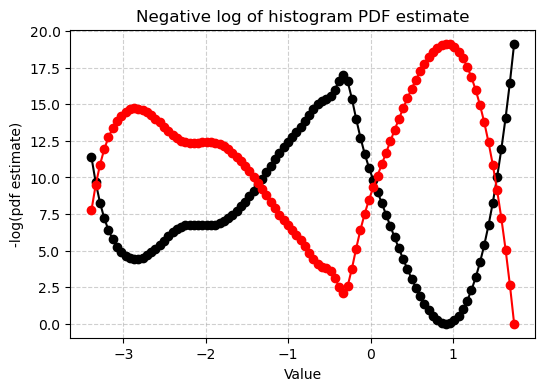

In [122]:
plt.figure(figsize=(6,4))
plt.plot(r_grid, -kt * logpdf, marker='o', linestyle='-', color='black')
plt.plot(r_grid, bias, marker='o', linestyle='-', color='red')
plt.xlabel("Value")
plt.ylabel("-log(pdf estimate)")
plt.title("Negative log of histogram PDF estimate")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [123]:
np.save('bias/metad_rerun_bias.npy',np.vstack([r_grid,bias]).T)

In [124]:
bias = np.load('bias/metad_rerun_bias.npy')
bias.shape

(100, 2)

#### 1. Metadynamics Rerun


##### 1.1 2d Muller potential

In [125]:
#%%time
# Biasfactor
biasfactor = 2
# Number of repeats for error bars
n_repeats = 10
# Simulation length
n_iters = 100000
 
torchforce_savedir = 'models/muller_2d_torchforce.pt'
bias = np.load('bias/metad_rerun_bias.npy')

for n_re in range(n_repeats):
    print('Running {n_re}/{n_repeats} Repeated Experiment ...'.format(
        n_re = n_re, n_repeats = n_repeats
    ))
    
    save_dir = 'traj_and_dat/2d_muller/metad_rerun/{n_iters}_gamma={biasfactor}_metad_rerun_{n_re}.npy'.format(
        biasfactor = biasfactor, n_iters = n_iters, n_re = n_re
    )
    
    # data in shape(no. of sims, no. of steps, 5), 5 for x, y, r, boltzmann factor, girsanov factor
    data = np.zeros((n_iters,5))
    
    # starting metad rerun simulation at the top-left basin
    starting_position = np.array([[-0.57,1.43,0]])
    ### Re-build systems, since LangevinSplittingGirsanov has weird behaviour when
    ### using context.reinitialize()
    system = System()
    systemforce = MullerForce()
    system.addParticle(mass)
    systemforce.addParticle(0, [])
    system.addForce(systemforce)

    # Converged metadynamics bias
    bias_grid = Continuous1DFunction(bias[:,1],bias[:,0][0],bias[:,0][-1])
    cv = TorchForce(torchforce_savedir)
    biasforce = CustomCVForce('(1-1/{biasfactor})*bias_grid(cv)'.format(biasfactor=biasfactor))
    biasforce.addCollectiveVariable('cv',cv)
    biasforce.addTabulatedFunction('bias_grid',bias_grid)
    biasforce.setForceGroup(1)
    system.addForce(biasforce)

    topology = app.Topology()
    
    # Langevin integrator that allows girsanov reweighting factor output
    integrator = LangevinSplittingGirsanov(
        nstxout = nstxout, temperature = temperature,
        collision_rate = collision_rate, timestep = timestep,
        splitting = splitting
    )

    # Create simulation
    simulation = Simulation(topology,system,integrator,platform)
    simulation.context.setPositions(starting_position)
    simulation.context.setVelocitiesToTemperature(temperature)
    
    for k in range(n_iters):
        if k % 100 == 0:
            print(str(k)+'/'+str(n_iters))
        # Record Positions
        data[k,:2] = simulation.context.getState(
            getPositions=True
        ).getPositions(asNumpy=True).value_in_unit(nanometer)[0,:2]
        # Record Boltzmann weight
        bias_potential = simulation.context.getState(
            getEnergy=True,groups=0b00000000000000000000000000000010
        ).getPotentialEnergy().value_in_unit(kilojoules_per_mole)
        data[k,3] = np.exp(bias_potential / kt)
        # Step simulation
        simulation.step(nstxout)
        # Record Girsanov weight
        data[k,4] = simulation.integrator.getGlobalVariableByName("M")
    
    data[:,2] = fmrc.transform(tica.transform(data[:,:2])).reshape(-1,)
    
    np.save(save_dir,data)

Running 0/10 Repeated Experiment ...
0/100000
100/100000
200/100000
300/100000
400/100000
500/100000
600/100000
700/100000
800/100000
900/100000
1000/100000
1100/100000
1200/100000
1300/100000
1400/100000
1500/100000
1600/100000
1700/100000
1800/100000
1900/100000
2000/100000
2100/100000
2200/100000
2300/100000
2400/100000
2500/100000
2600/100000
2700/100000
2800/100000
2900/100000
3000/100000
3100/100000
3200/100000
3300/100000
3400/100000
3500/100000
3600/100000
3700/100000
3800/100000
3900/100000
4000/100000
4100/100000
4200/100000
4300/100000
4400/100000
4500/100000
4600/100000
4700/100000
4800/100000
4900/100000
5000/100000
5100/100000
5200/100000
5300/100000
5400/100000
5500/100000
5600/100000
5700/100000
5800/100000
5900/100000
6000/100000
6100/100000
6200/100000
6300/100000
6400/100000
6500/100000
6600/100000
6700/100000
6800/100000
6900/100000
7000/100000
7100/100000
7200/100000
7300/100000
7400/100000
7500/100000
7600/100000
7700/100000
7800/100000
7900/100000
8000/100000
810

###### 2d bias

In [19]:
#%%time
# Number of repeats for error bars
n_repeats = 10
# Simulation length
n_iters = 100000

for n_re in range(n_repeats):
    print('Running {n_re}/{n_repeats} Repeated Experiment ...'.format(
        n_re = n_re, n_repeats = n_repeats
    ))
    # data in shape(no. of sims, no. of steps, 4), 4 for x, y, boltzmann factor, girsanov factor
    save_dir = 'traj_and_dat/2d_muller/metad_rerun/{n_iters}_gamma={biasfactor}_metad_rerun_{n_re}.npy'.format(
        biasfactor = biasfactor, n_iters = n_iters, n_re = n_re
    )
    data = np.zeros((n_iters,4))
    
    # starting metad rerun simulation at the top-left basin
    starting_position = np.array([[-0.57,1.43,0]])
    ### Re-build systems, since LangevinSplittingGirsanov has weird behaviour when
    ### using context.reinitialize()
    system = System()
    systemforce = MullerForce()
    system.addParticle(mass)
    systemforce.addParticle(0, [])
    system.addForce(systemforce)

    # Converged metadynamics bias
    bias = CustomExternalForce('(1/{biasfactor}-1)*('.format(biasfactor=biasfactor)+systemforce.expression+')')
    bias.setForceGroup(1)
    bias.addParticle(0,[])
    system.addForce(bias)

    topology = app.Topology()
    
    # Langevin integrator that allows girsanov reweighting factor output
    integrator = LangevinSplittingGirsanov(
        nstxout = nstxout, temperature = temperature,
        collision_rate = collision_rate, timestep = timestep,
        splitting = splitting
    )

    # Create simulation
    simulation = Simulation(topology,system,integrator,platform)
    simulation.context.setPositions(starting_position)
    simulation.context.setVelocitiesToTemperature(temperature)
    
    for k in range(n_iters):
        if k % 100 == 0:
            print(str(k)+'/'+str(n_iters))
        # Record Positions
        data[k,:2] = simulation.context.getState(
            getPositions=True
        ).getPositions(asNumpy=True).value_in_unit(nanometer)[0,:2]
        # Record Boltzmann weight
        bias_potential = simulation.context.getState(
            getEnergy=True,groups=0b00000000000000000000000000000010
        ).getPotentialEnergy().value_in_unit(kilojoules_per_mole)
        data[k,2] = np.exp(bias_potential / kt)
        # Step simulation
        simulation.step(nstxout)
        # Record Girsanov weight
        data[k,3] = simulation.integrator.getGlobalVariableByName("M")
    np.save(save_dir,data)

Running 0/10 Repeated Experiment ...
0/100000
100/100000
200/100000
300/100000
400/100000
500/100000
600/100000
700/100000
800/100000
900/100000
1000/100000
1100/100000
1200/100000
1300/100000
1400/100000
1500/100000
1600/100000
1700/100000
1800/100000
1900/100000
2000/100000
2100/100000
2200/100000
2300/100000
2400/100000
2500/100000
2600/100000
2700/100000
2800/100000
2900/100000
3000/100000
3100/100000
3200/100000
3300/100000
3400/100000
3500/100000
3600/100000
3700/100000
3800/100000
3900/100000
4000/100000
4100/100000
4200/100000
4300/100000
4400/100000
4500/100000
4600/100000
4700/100000
4800/100000
4900/100000
5000/100000
5100/100000
5200/100000
5300/100000
5400/100000
5500/100000
5600/100000
5700/100000
5800/100000
5900/100000
6000/100000
6100/100000
6200/100000
6300/100000
6400/100000
6500/100000
6600/100000
6700/100000
6800/100000
6900/100000
7000/100000
7100/100000
7200/100000
7300/100000
7400/100000
7500/100000
7600/100000
7700/100000
7800/100000
7900/100000
8000/100000
810

#### 3. Metadynamics build-up simulation

##### 3.1 2d Muller Potential

In [126]:
# Metadynamics parameters
biasfactor = 2
cv_sigma = 0.1
periodic_cv = False
gridwidth = 100
height = 1.2 * kilojoule_per_mole
pace = 20

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [128]:
#%%time
# Number of repeats for error bars
n_repeats = 10
# Simulation length
n_iters = 100000

torchforce_savedir = 'models/muller_2d_torchforce.pt'
# Load the grid points so that this simulation is consistent with the rerun one
bias = np.load('bias/metad_rerun_bias.npy')

for n_re in range(n_repeats):
    print('Running {n_re}/{n_repeats} Repeated Experiment ...'.format(
        n_re = n_re, n_repeats = n_repeats
    ))

    save_dir = 'traj_and_dat/2d_muller/metad_build_up/{n_iters}_gamma={biasfactor}_metad_build_up_{n_re}.npy'.format(
        biasfactor = biasfactor, n_iters = n_iters, n_re = n_re
    )
    
    # data in shape(no. of sims, no. of steps, 5), 5 for x, y, r, boltzmann factor, girsanov factor
    data = np.zeros((n_iters,5))
    
    # starting metad rerun simulation at the top-left basin
    starting_position = np.array([[-0.57,1.43,0]])
    ### Re-build systems, since LangevinSplittingGirsanov has weird behaviour when
    ### using context.reinitialize()
    system = System()
    systemforce = MullerForce()
    system.addParticle(mass)
    systemforce.addParticle(0, [])
    system.addForce(systemforce)

    # Define the collective variable as x
    cv_force = TorchForce(torchforce_savedir)
    
    # Create the BiasVariable and Metadynamics objects
    cv = BiasVariable(
        cv_force, bias[:,0][0], bias[:,0][-1], cv_sigma, periodic_cv, gridwidth
    )
        
    metad = Metadynamics(
        system, [cv], temperature, biasfactor, height, pace#, save_freq, save_dir
    )
    
    # Set ForceGroup to 1 for Girsanov path weights
    metad._force.setForceGroup(1)

    topology = app.Topology()
    
    # Langevin integrator that allows girsanov reweighting factor output
    integrator = LangevinSplittingGirsanov(
        nstxout = nstxout, temperature = temperature,
        collision_rate = collision_rate, timestep = timestep,
        splitting = splitting
    )

    # Create simulation
    simulation = Simulation(topology,system,integrator,platform)
    simulation.context.setPositions(starting_position)
    simulation.context.setVelocitiesToTemperature(temperature)
    
    for k in range(n_iters):
        if k % 100 == 0:
            print(str(k)+'/'+str(n_iters))
        # Record Positions
        data[k,:2] = simulation.context.getState(
            getPositions=True
        ).getPositions(asNumpy=True).value_in_unit(nanometer)[0,:2]
        # Step simulation
        metad.step(simulation,nstxout)
        # Record Girsanov weight
        data[k,4] = simulation.integrator.getGlobalVariableByName("M")

    data[:,2] = fmrc.transform(tica.transform(data[:,:2])).reshape(-1,)
    # End-point bias potential reweighting: assuming pseudo-static bias
    # Retrieve the bias grid
    bias_grid = np.array(metad._table.getFunctionParameters()[0])
    cv_grid = np.linspace(bias[:,0][0],bias[:,0][-1],bias_grid.shape[0])
    # Re-construct the cubic spline
    spline = CubicSpline(cv_grid,bias_grid,bc_type='natural')
    data[:,3] = np.exp(spline(data[:,2])/kt)
    # For values outside the grid, the bias value should be 0
    data[:,3][np.where((data[:,2]<bias[:,0][0]) | (data[:,2] > bias[:,0][-1]))] = 1.0 
    np.save(save_dir,data)

Running 0/10 Repeated Experiment ...
0/100000
100/100000
200/100000
300/100000
400/100000
500/100000
600/100000
700/100000
800/100000
900/100000
1000/100000
1100/100000
1200/100000
1300/100000
1400/100000
1500/100000
1600/100000
1700/100000
1800/100000
1900/100000
2000/100000
2100/100000
2200/100000
2300/100000
2400/100000
2500/100000
2600/100000
2700/100000
2800/100000
2900/100000
3000/100000
3100/100000
3200/100000
3300/100000
3400/100000
3500/100000
3600/100000
3700/100000
3800/100000
3900/100000
4000/100000
4100/100000
4200/100000
4300/100000
4400/100000
4500/100000
4600/100000
4700/100000
4800/100000
4900/100000
5000/100000
5100/100000
5200/100000
5300/100000
5400/100000
5500/100000
5600/100000
5700/100000
5800/100000
5900/100000
6000/100000
6100/100000
6200/100000
6300/100000
6400/100000
6500/100000
6600/100000
6700/100000
6800/100000
6900/100000
7000/100000
7100/100000
7200/100000
7300/100000
7400/100000
7500/100000
7600/100000
7700/100000
7800/100000
7900/100000
8000/100000
810